In [233]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [234]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
from model.linear_model import LinearModel

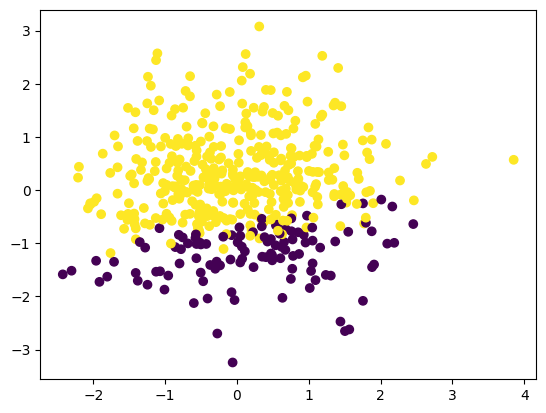

In [235]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

## Functions

In [236]:
# # loading data
# loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

# X = loaded_data['X_data']
# y = loaded_data['y_data']
# W = loaded_data['W_data']

# # Show the size of data
# print(f"X size : {X.shape}, y size : {y.shape}")

# # Make sure size and dim correct.
# size = X.shape[0]
# dim = X.shape[1]-1

def load_data(tgt_data):
    # loading data
    loaded_data = np.load(f'data/logistic_data/logistic_data_{tgt_data}.npz')

    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']

    # Show the size of data
    print(f"X size : {X.shape}, y size : {y.shape}")

    # Make sure size and dim correct.
    size = X.shape[0]
    dim = X.shape[1]-1

    return X, y, W, size, dim


def train_model(tgt_data, lr=0.01, n_iteration=500, val_ratio=0.2, draw_scatter=False):
    # RANDOM SEED DECLEARED HERE
    seed = 42 # do not change the seed
    np.random.seed(seed)
    X, y, W, size, dim = load_data(tgt_data)

    # Setting loss function, gradient, and activation function.
    loss_fn = logloss
    act_fn = sigmoid
    grad_fn = logloss_sigmoid_grad

    #Split dataset to train dataset and validation dataset
    X_train,y_train,X_val,y_val = get_train_val(X,y)

    # Setting model and starting training
    model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
    model.fit(X_train,y_train,lr=lr,n_iteration = n_iteration,val_ratio=0.2)

    # Predicting on validation dataset
    y_val_pred = model.predict(X_val)
    # evaluate model performance
    evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}')

    if (draw_scatter):
        # Plot
        x_min, x_max = X_val[:, 1].min(), X_val[:, 1].max()
        y_min, y_max = X_val[:, 2].min(), X_val[:, 2].max()

        # Add a small margin so points/boundary are not flush with axes
        x_margin = 0.05 * (x_max - x_min)
        y_margin = 0.05 * (y_max - y_min)

        x_plot_min, x_plot_max = x_min - x_margin, x_max + x_margin
        y_plot_min, y_plot_max = y_min - y_margin, y_max + y_margin
        plt.figure(figsize=(4, 3))
        plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)

        # Decision boundary from model weights: w0 + w1*x1 + w2*x2 = 0
        ex1 = np.linspace(x_plot_min, x_plot_max, 200)
        ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
        plt.plot(ex1, ex2, color='r', label='decision boundary')
        plt.xlim(x_plot_min, x_plot_max)
        plt.ylim(y_plot_min, y_plot_max)
        plt.legend()
        plt.show()

### Logistic dataset A
#### lr = 0.1

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.31865436882587583, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.29183663203624455
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.22467783764966348, Val loss:0.2455615161221097
350. Training loss: 0.21624915555159707, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419928, Val loss:0.23190816484103666
450. Training loss: 0.2043156331315366, Val loss:0.2270843249497499
500. Training loss: 0.19991967899618934, Val loss:0.22311586759002253


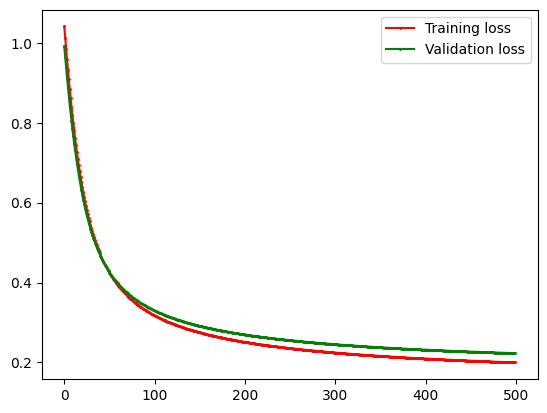

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


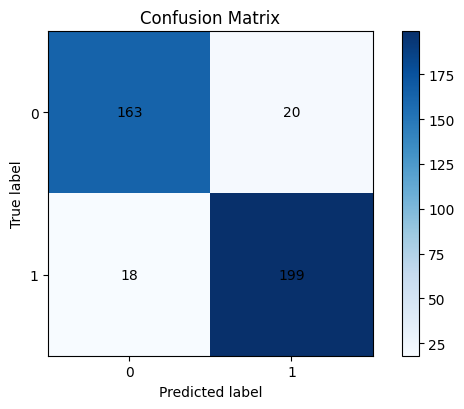

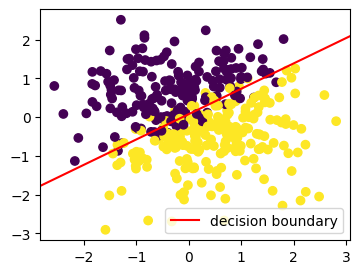

In [237]:
train_model(tgt_data="A",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.700717653642279
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.502528798587891, Val loss:0.5015278107602668
400. Training loss: 0.472286903656601, Val loss:0.4733528541640398
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430734, Val loss:0.43054684173876917


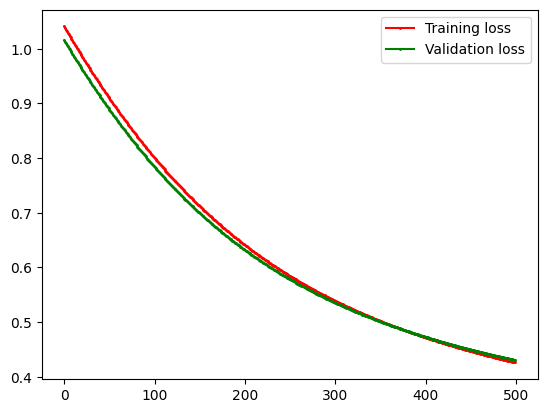

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


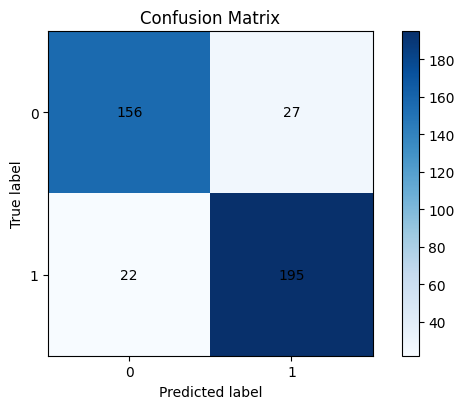

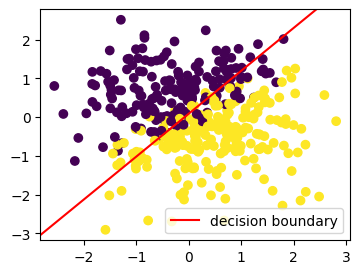

In [238]:
train_model(tgt_data="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (2000, 3), y size : (2000,)
50. Training loss: 1.0269460601586051, Val loss:1.0044831492028101
100. Training loss: 1.0129964397614701, Val loss:0.9909719737552948
150. Training loss: 0.9992783487558338, Val loss:0.9776880822134313
200. Training loss: 0.9857916009817304, Val loss:0.9646313599916955
250. Training loss: 0.9725358539101562, Val loss:0.9518015338881938
300. Training loss: 0.9595106080951762, Val loss:0.9391981713655223
350. Training loss: 0.9467152071471594, Val loss:0.9268206803770205
400. Training loss: 0.9341488382362757, Val loss:0.9146683097467531
450. Training loss: 0.921810533131396, Val loss:0.902740150107322
500. Training loss: 0.909699169775372, Val loss:0.8910351353952262


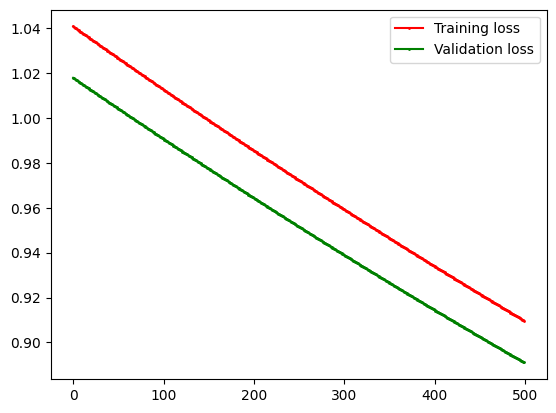

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.3875
Precision : 0.4364
Recall    : 0.4424
F1-score  : 0.4394


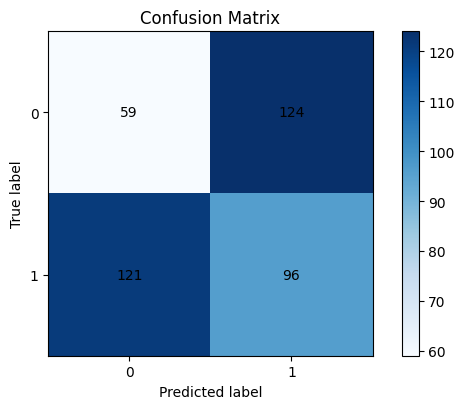

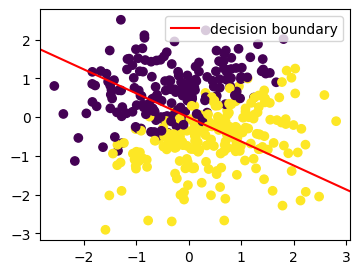

In [239]:
train_model(tgt_data="A",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (A) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.700717653642279
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.502528798587891, Val loss:0.5015278107602668
400. Training loss: 0.472286903656601, Val loss:0.4733528541640398
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430734, Val loss:0.43054684173876917


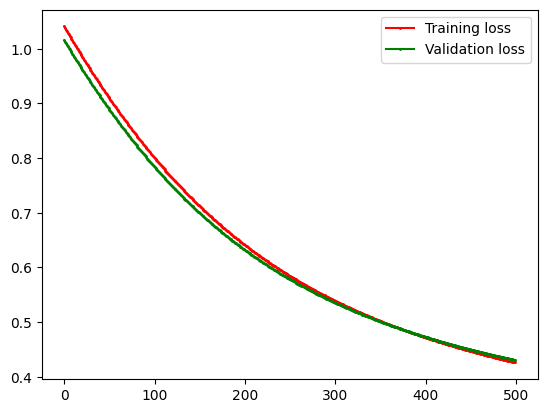

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


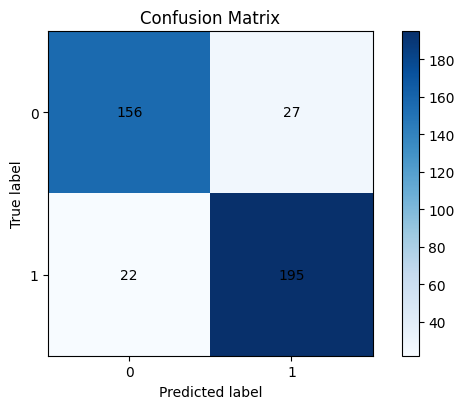

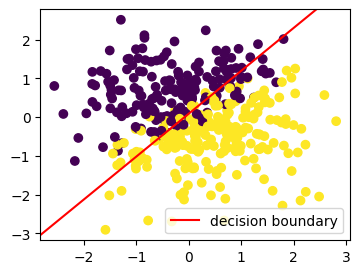

In [240]:
train_model(tgt_data="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.700717653642279
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.502528798587891, Val loss:0.5015278107602668
400. Training loss: 0.472286903656601, Val loss:0.4733528541640398
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430734, Val loss:0.43054684173876917
550. Training loss: 0.4081728908570478, Val loss:0.41397464715417137
600. Training loss: 0.39272216283590494, Val loss:0.3997327089757893
650. Training loss: 0.3792774530955585, Val loss:0.3873588962090099
700. Training loss: 0.3674662456334752, Val loss:0.3765019336049602
750. Traini

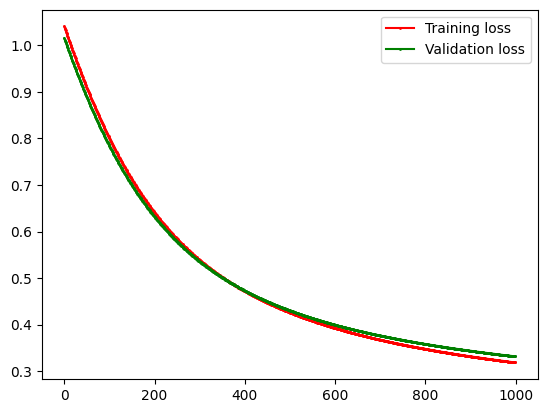

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9025
Precision : 0.9045
Recall    : 0.9171
F1-score  : 0.9108


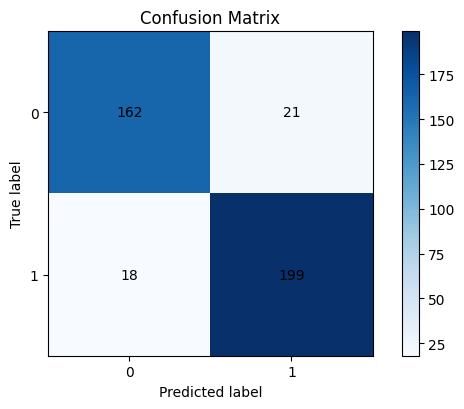

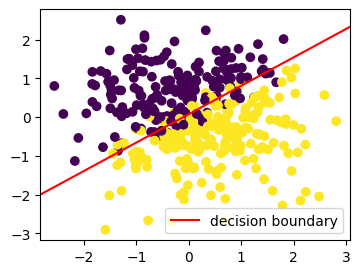

In [241]:
train_model(tgt_data="A",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.700717653642279
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.502528798587891, Val loss:0.5015278107602668
400. Training loss: 0.472286903656601, Val loss:0.4733528541640398
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430734, Val loss:0.43054684173876917
550. Training loss: 0.4081728908570478, Val loss:0.41397464715417137
600. Training loss: 0.39272216283590494, Val loss:0.3997327089757893
650. Training loss: 0.3792774530955585, Val loss:0.3873588962090099
700. Training loss: 0.3674662456334752, Val loss:0.3765019336049602
750. Traini

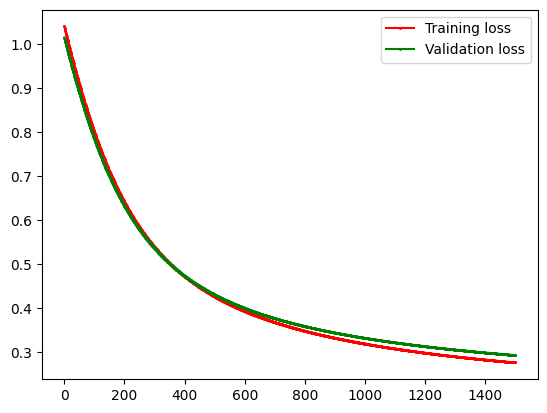

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


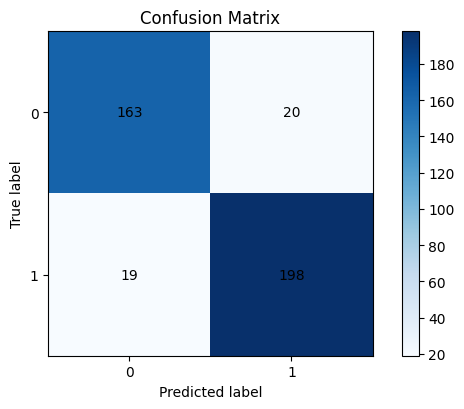

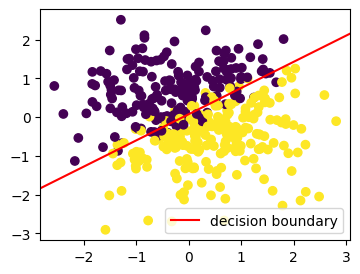

In [242]:
train_model(tgt_data="A",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset B
#### lr = 0.1

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.5103175622043802, Val loss:0.5083432819772871
100. Training loss: 0.4370955155097443, Val loss:0.4380558711885709
150. Training loss: 0.41557622016883045, Val loss:0.41686490530445874
200. Training loss: 0.4064609166991815, Val loss:0.40772460423377516
250. Training loss: 0.40189820214342353, Val loss:0.403075856575893
300. Training loss: 0.39939491697142937, Val loss:0.40048112134177466
350. Training loss: 0.39794090751624056, Val loss:0.39894289148678264
400. Training loss: 0.3970632739456962, Val loss:0.3979910069463985
450. Training loss: 0.39651887299277677, Val loss:0.3973823809390223
500. Training loss: 0.39617431232724015, Val loss:0.3969828690264412


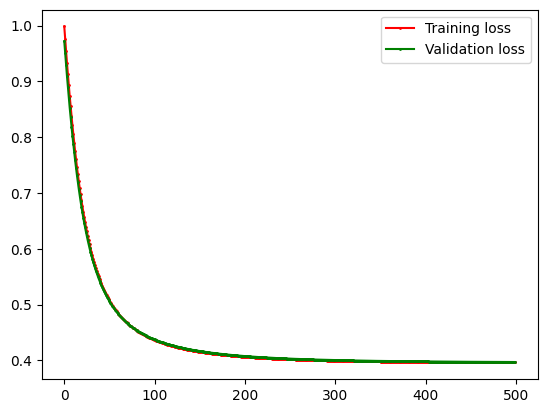

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


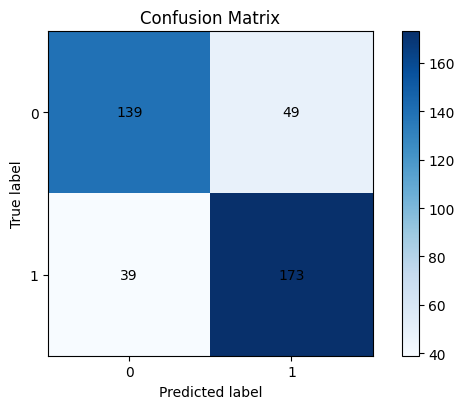

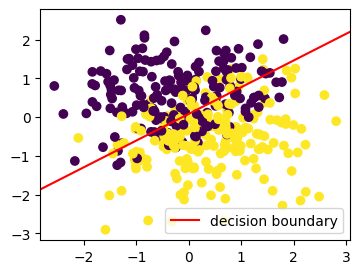

In [243]:
train_model(tgt_data="B",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.808309646735232, Val loss:0.804210107205688
150. Training loss: 0.7369603264945956, Val loss:0.7337661725077594
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195073, Val loss:0.632045314833689
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962921, Val loss:0.5673195097222041
400. Training loss: 0.5441528833412148, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803


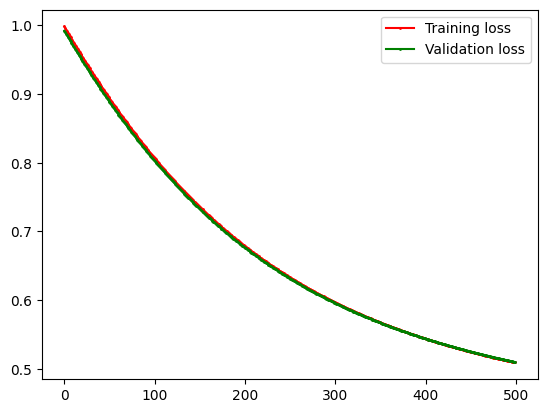

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


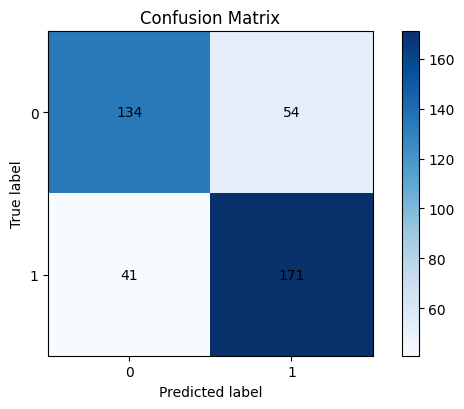

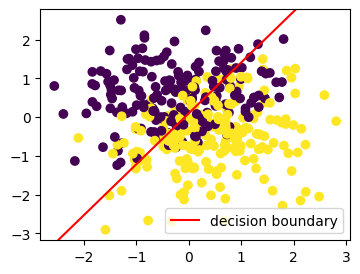

In [244]:
train_model(tgt_data="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9874379008463233, Val loss:0.9833381665312408
100. Training loss: 0.9763421106130916, Val loss:0.9723285004243568
150. Training loss: 0.9654284713499054, Val loss:0.9614993121069902
200. Training loss: 0.9546966109038486, Val loss:0.9508503118676398
250. Training loss: 0.9441460548822513, Val loss:0.9403811053688884
300. Training loss: 0.9337762268335359, Val loss:0.9300911936941736
350. Training loss: 0.9235864487116805, Val loss:0.9199799736931847
400. Training loss: 0.9135759416259137, Val loss:0.9100467386272083
450. Training loss: 0.9037438268754272, Val loss:0.900290679113813
500. Training loss: 0.8940891272670412, Val loss:0.8907108843683351


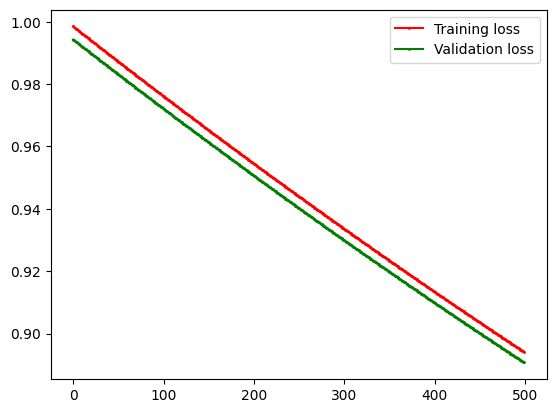

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.3925
Precision : 0.4286
Recall    : 0.4387
F1-score  : 0.4336


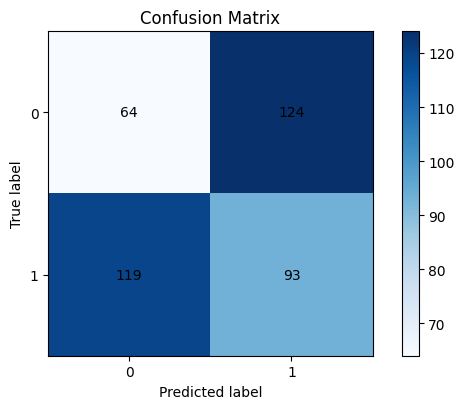

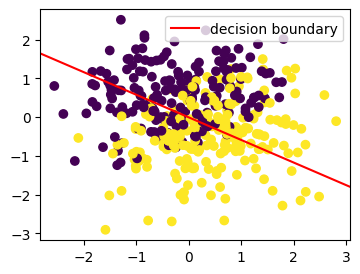

In [245]:
train_model(tgt_data="B",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (B) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.808309646735232, Val loss:0.804210107205688
150. Training loss: 0.7369603264945956, Val loss:0.7337661725077594
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195073, Val loss:0.632045314833689
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962921, Val loss:0.5673195097222041
400. Training loss: 0.5441528833412148, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803


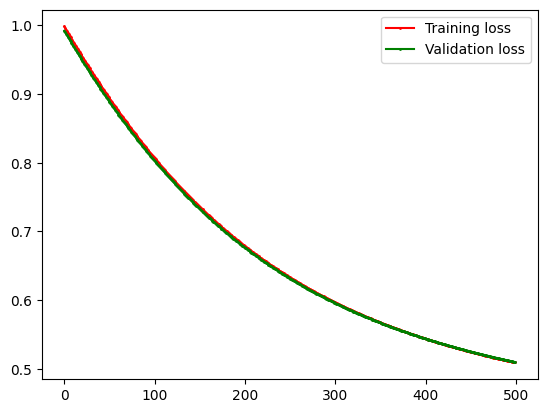

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


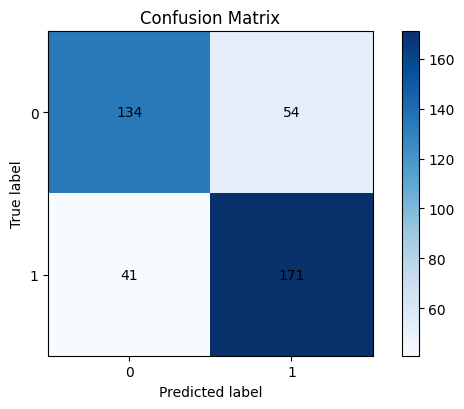

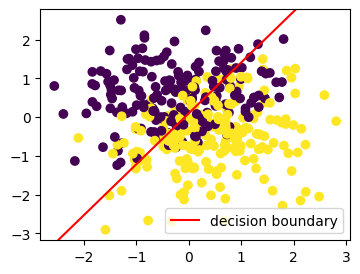

In [246]:
train_model(tgt_data="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.808309646735232, Val loss:0.804210107205688
150. Training loss: 0.7369603264945956, Val loss:0.7337661725077594
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195073, Val loss:0.632045314833689
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962921, Val loss:0.5673195097222041
400. Training loss: 0.5441528833412148, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803
550. Training loss: 0.49587540253738227, Val loss:0.4967249285603096
600. Training loss: 0.48481807604794447, Val loss:0.4858517431539401
650. Training loss: 0.47544801408599957, Val loss:0.4766264014194725
700. Training loss: 0.4674382470338402, Val loss:0.4687295376448458
750. Trainin

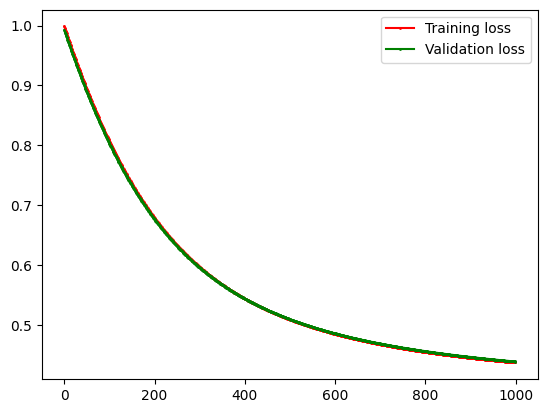

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


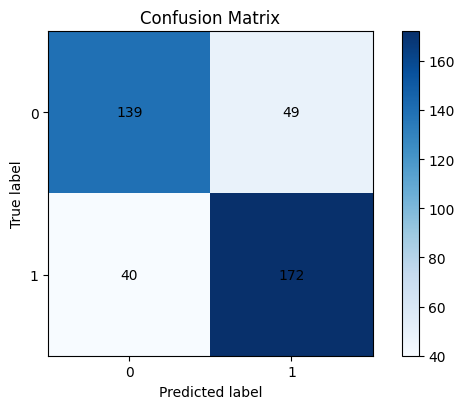

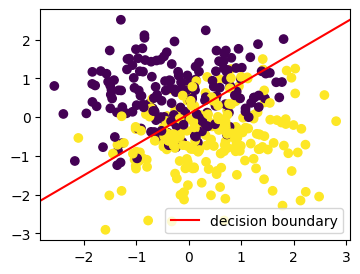

In [247]:
train_model(tgt_data="B",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.808309646735232, Val loss:0.804210107205688
150. Training loss: 0.7369603264945956, Val loss:0.7337661725077594
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195073, Val loss:0.632045314833689
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962921, Val loss:0.5673195097222041
400. Training loss: 0.5441528833412148, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803
550. Training loss: 0.49587540253738227, Val loss:0.4967249285603096
600. Training loss: 0.48481807604794447, Val loss:0.4858517431539401
650. Training loss: 0.47544801408599957, Val loss:0.4766264014194725
700. Training loss: 0.4674382470338402, Val loss:0.4687295376448458
750. Trainin

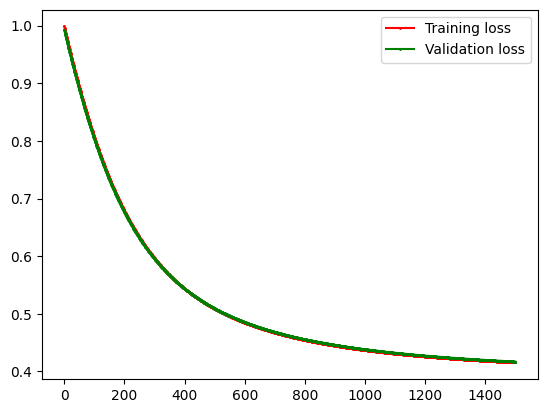

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


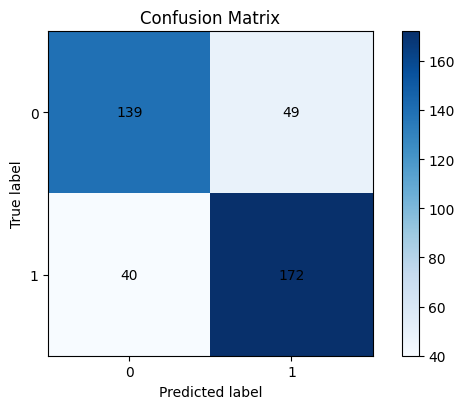

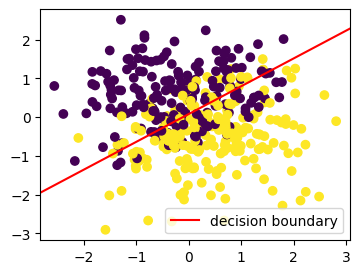

In [248]:
train_model(tgt_data="B",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset C
#### lr = 0.1`

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.2914041500436065, Val loss:0.3046140440301792
100. Training loss: 0.24213528492723757, Val loss:0.25808888358348697
150. Training loss: 0.21536654598435145, Val loss:0.23224845658563792
200. Training loss: 0.19747326685613661, Val loss:0.21464876637946464
250. Training loss: 0.18425966445090686, Val loss:0.20146358893625357
300. Training loss: 0.17392662515639432, Val loss:0.19104062396513338
350. Training loss: 0.1655356333407847, Val loss:0.18250642396014666
400. Training loss: 0.15853434715164158, Val loss:0.17533939085232825
450. Training loss: 0.15257074008482724, Val loss:0.1692025922688029
500. Training loss: 0.14740737629117945, Val loss:0.16386616021059383


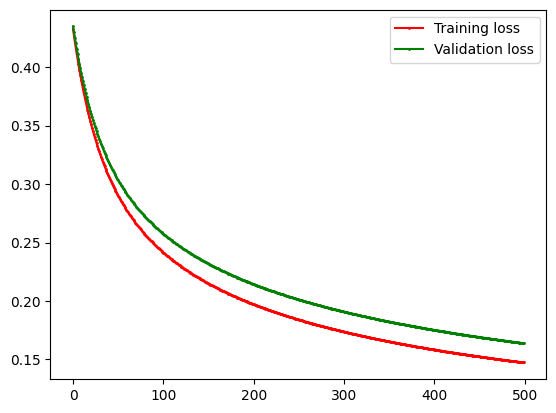

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


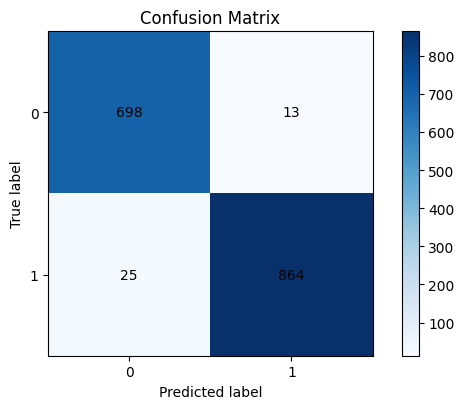

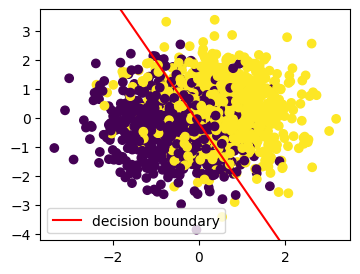

In [249]:
train_model(tgt_data="C",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.37826386485051927
200. Training loss: 0.3519542394733583, Val loss:0.36332831682999583
250. Training loss: 0.33827534357025285, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.3290240082767375
400. Training loss: 0.3064235064986363, Val loss:0.3201340925514732
450. Training loss: 0.29805473954887807, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056


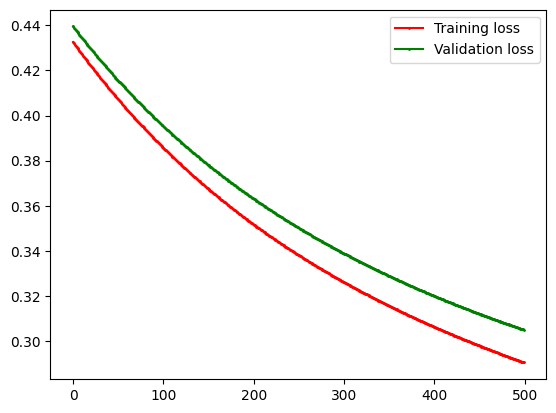

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


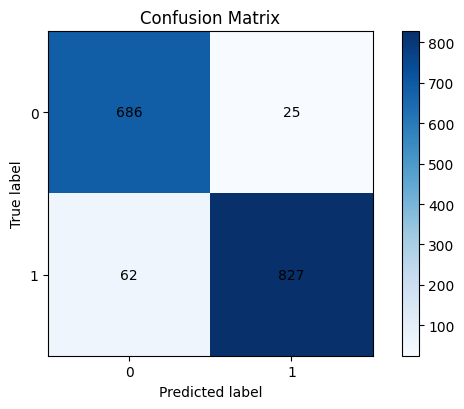

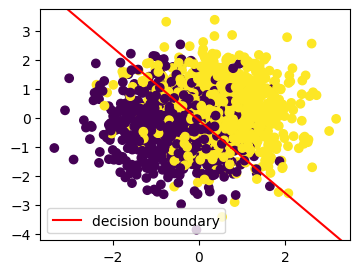

In [250]:
train_model(tgt_data="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4298821030676496, Val loss:0.43740830867066577
100. Training loss: 0.4271883654785384, Val loss:0.43486105109553536
150. Training loss: 0.42454112656343235, Val loss:0.4323574765831896
200. Training loss: 0.42193938784995444, Val loss:0.42989664927305665
250. Training loss: 0.4193821724637837, Val loss:0.4274776538321253
300. Training loss: 0.41686852479007863, Val loss:0.4250995951031024
350. Training loss: 0.41439751012942966, Val loss:0.42276159774950733
400. Training loss: 0.4119682143493205, Val loss:0.4204628058985884
450. Training loss: 0.40957974353201126, Val loss:0.4182023827828775
500. Training loss: 0.40723122361969855, Val loss:0.4159795103811309


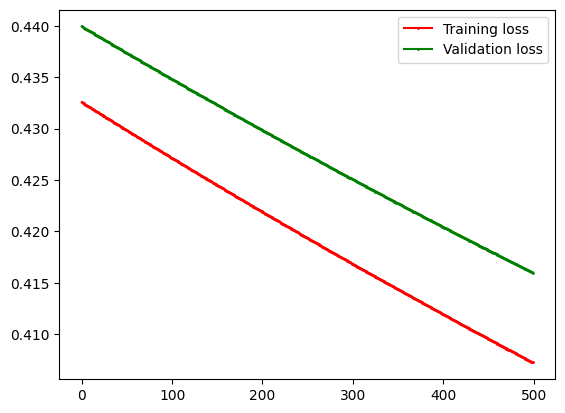

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8406
Precision : 0.8774
Recall    : 0.8290
F1-score  : 0.8525


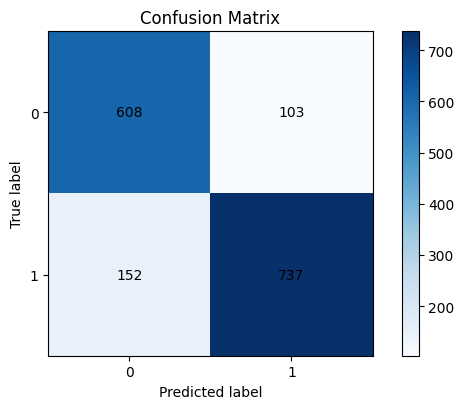

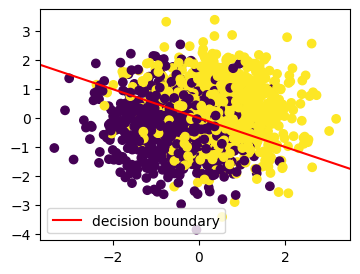

In [251]:
train_model(tgt_data="C",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (C) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.37826386485051927
200. Training loss: 0.3519542394733583, Val loss:0.36332831682999583
250. Training loss: 0.33827534357025285, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.3290240082767375
400. Training loss: 0.3064235064986363, Val loss:0.3201340925514732
450. Training loss: 0.29805473954887807, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056


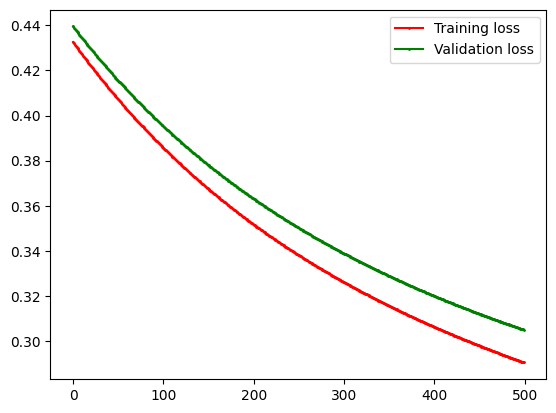

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


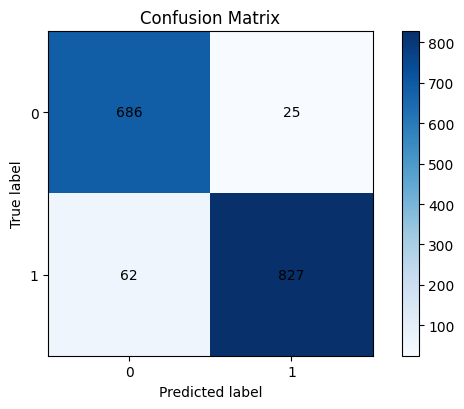

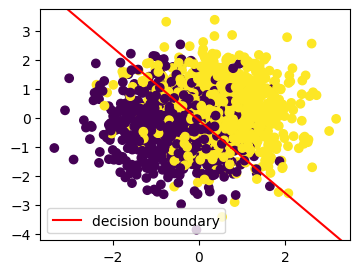

In [252]:
train_model(tgt_data="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.37826386485051927
200. Training loss: 0.3519542394733583, Val loss:0.36332831682999583
250. Training loss: 0.33827534357025285, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.3290240082767375
400. Training loss: 0.3064235064986363, Val loss:0.3201340925514732
450. Training loss: 0.29805473954887807, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056
550. Training loss: 0.28369081715291194, Val loss:0.29849682447858894
600. Training loss: 0.2774673815390825, Val loss:0.29256047251983547
650. Training loss: 0.27176454986406984, Val loss:0.28711426402309975
700. Training loss: 0.26651273728471975, Val loss:0.28209239966841

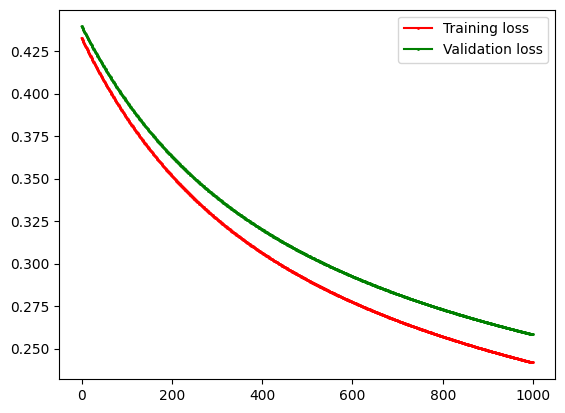

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9744
Precision : 0.9885
Recall    : 0.9651
F1-score  : 0.9767


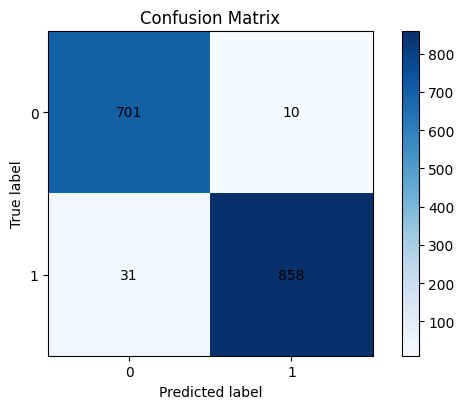

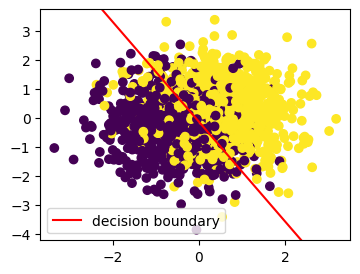

In [253]:
train_model(tgt_data="C",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.37826386485051927
200. Training loss: 0.3519542394733583, Val loss:0.36332831682999583
250. Training loss: 0.33827534357025285, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.3290240082767375
400. Training loss: 0.3064235064986363, Val loss:0.3201340925514732
450. Training loss: 0.29805473954887807, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056
550. Training loss: 0.28369081715291194, Val loss:0.29849682447858894
600. Training loss: 0.2774673815390825, Val loss:0.29256047251983547
650. Training loss: 0.27176454986406984, Val loss:0.28711426402309975
700. Training loss: 0.26651273728471975, Val loss:0.28209239966841

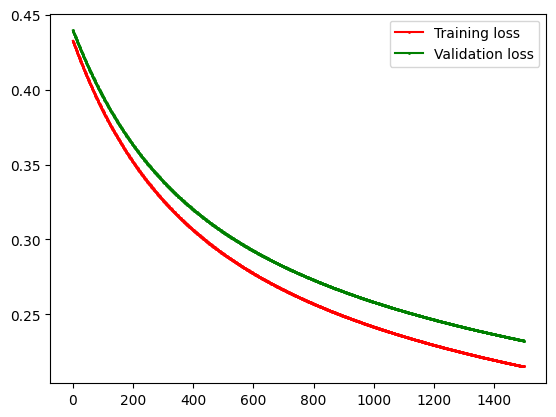

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9788
Precision : 0.9897
Recall    : 0.9719
F1-score  : 0.9807


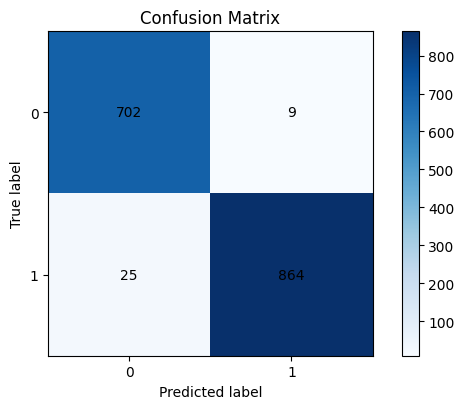

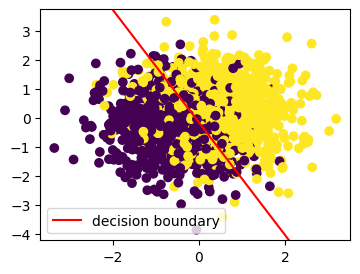

In [254]:
train_model(tgt_data="C",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset D
#### lr = 0.1`

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.31214565926023174, Val loss:0.3238995705537948
100. Training loss: 0.2680253579500514, Val loss:0.28459011684914537
150. Training loss: 0.24507991801016668, Val loss:0.2636714373900576
200. Training loss: 0.23025970529698725, Val loss:0.24981367489682632
250. Training loss: 0.21963615020155505, Val loss:0.23967468756947907
300. Training loss: 0.2115547767275018, Val loss:0.23184417444050132
350. Training loss: 0.20516346620008113, Val loss:0.22558274853425692
400. Training loss: 0.1999656677345639, Val loss:0.22044961112666256
450. Training loss: 0.19564762834057497, Val loss:0.21616005232291835
500. Training loss: 0.19199945372601435, Val loss:0.21251993712270312


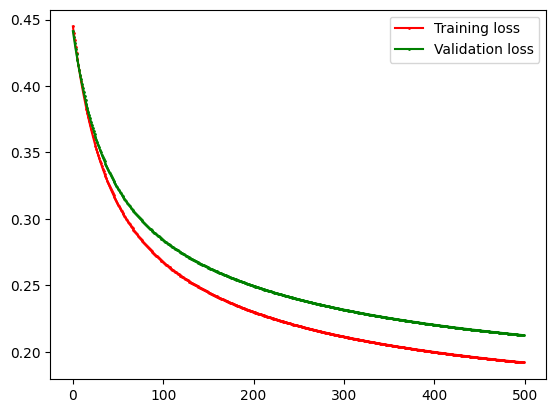

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


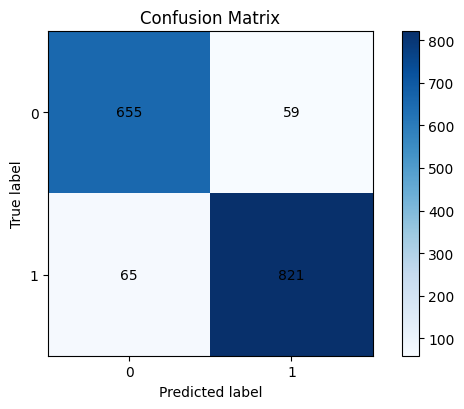

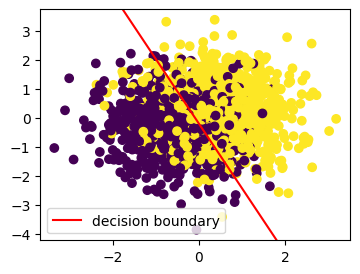

In [255]:
train_model(tgt_data="D",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4210863364107005, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.3444310989408412, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966


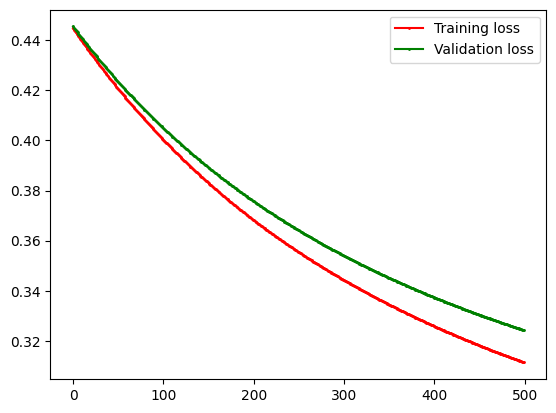

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


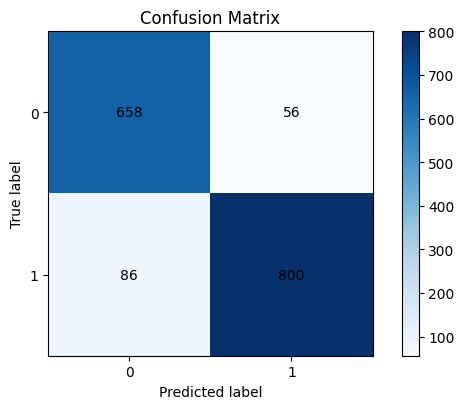

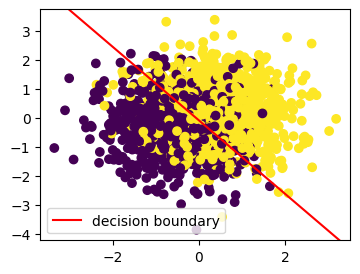

In [256]:
train_model(tgt_data="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.44221977024873604, Val loss:0.4436168074363421
100. Training loss: 0.4396594302179652, Val loss:0.4412701641807759
150. Training loss: 0.4371436725613987, Val loss:0.4389647208426862
200. Training loss: 0.4346715536135045, Val loss:0.4366996003801621
250. Training loss: 0.4322421495919633, Val loss:0.43447394458012223
300. Training loss: 0.4298545563023576, Val loss:0.43228691374881156
350. Training loss: 0.42750788883734553, Val loss:0.43013768639915717
400. Training loss: 0.42520128127118983, Val loss:0.4280254589357611
450. Training loss: 0.422933886350463, Val loss:0.4259494453382512
500. Training loss: 0.42070487518169253, Val loss:0.42390887684365186


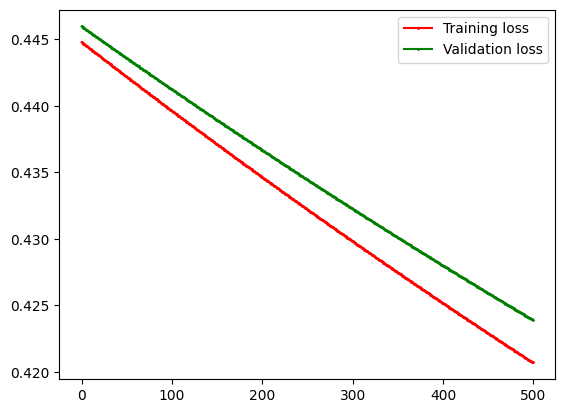

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8319
Precision : 0.8668
Recall    : 0.8228
F1-score  : 0.8442


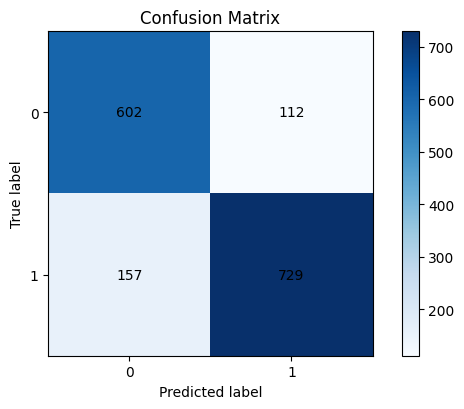

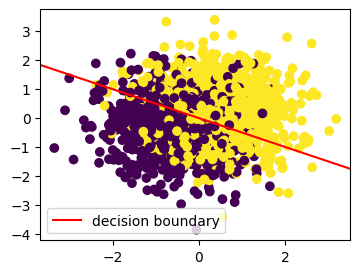

In [257]:
train_model(tgt_data="D",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (D) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4210863364107005, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.3444310989408412, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966


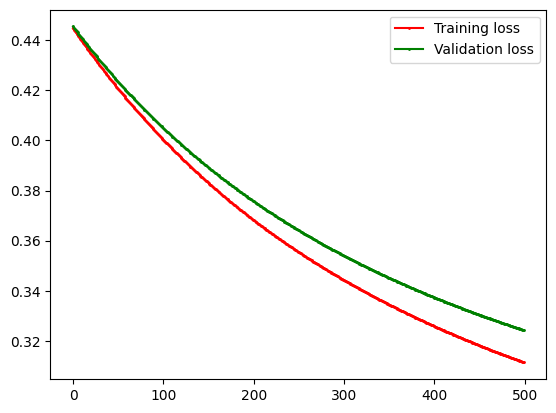

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


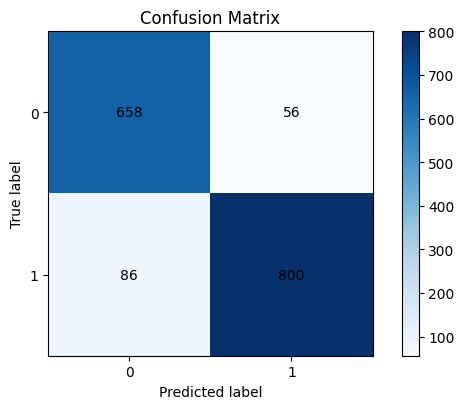

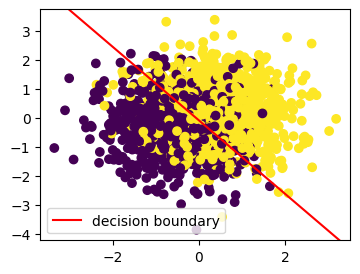

In [258]:
train_model(tgt_data="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4210863364107005, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.3444310989408412, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966
550. Training loss: 0.30512120261559816, Val loss:0.31861866833458574
600. Training loss: 0.2994739813818718, Val loss:0.31352230201213016
650. Training loss: 0.29432499674933427, Val loss:0.3088748500410424
700. Training loss: 0.28960656875428886, Val loss:0.304614130374186

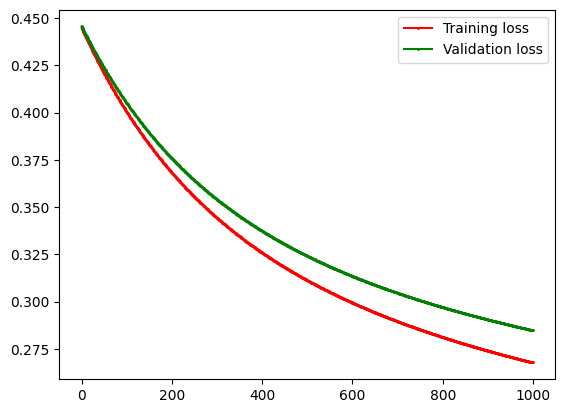

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9263
Precision : 0.9394
Recall    : 0.9266
F1-score  : 0.9330


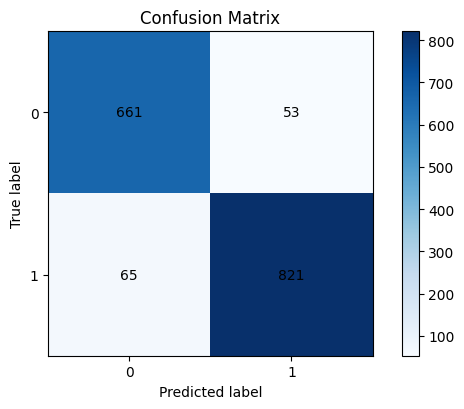

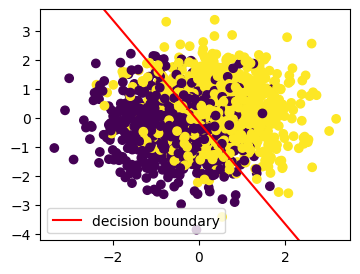

In [259]:
train_model(tgt_data="D",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4210863364107005, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.3444310989408412, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966
550. Training loss: 0.30512120261559816, Val loss:0.31861866833458574
600. Training loss: 0.2994739813818718, Val loss:0.31352230201213016
650. Training loss: 0.29432499674933427, Val loss:0.3088748500410424
700. Training loss: 0.28960656875428886, Val loss:0.304614130374186

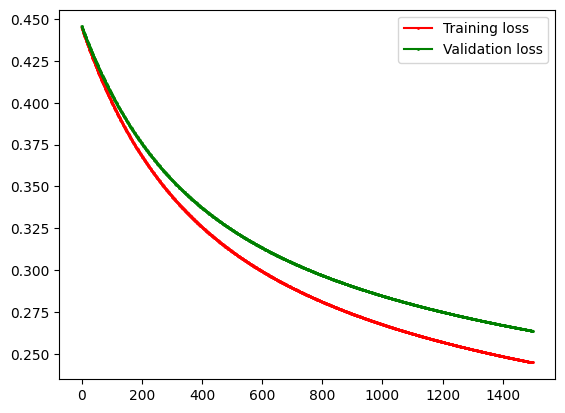

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9256
Precision : 0.9393
Recall    : 0.9255
F1-score  : 0.9323


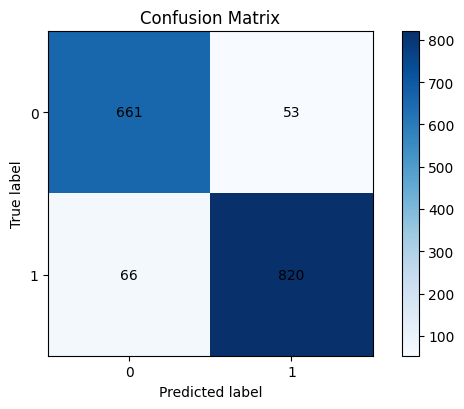

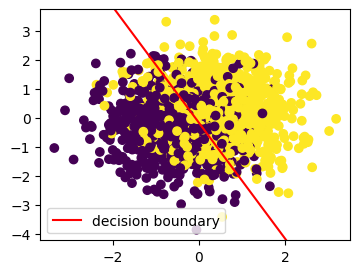

In [260]:
train_model(tgt_data="D",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

In [261]:
# # Train the model
# from model.linear_model import LinearModel

# seed = 42 # do not change the seed
# np.random.seed(seed)

# # Setting loss function, gradient, and activation function.
# loss_fn = logloss
# act_fn = sigmoid
# grad_fn = logloss_sigmoid_grad

# # Split dataset to train dataset and validation dataset
# X_train,y_train,X_val,y_val = get_train_val(X,y)

# # Setting model and starting training
# model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
# model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [262]:
# # Get the Prediction
# y_val_pred = model.predict(X_val)

In [263]:
# # Evaluation
# # Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
# evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

In [264]:
# # Plot
# x_min, x_max = X_val[:, 1].min(), X_val[:, 1].max()
# y_min, y_max = X_val[:, 2].min(), X_val[:, 2].max()

# # Add a small margin so points/boundary are not flush with axes
# x_margin = 0.05 * (x_max - x_min)
# y_margin = 0.05 * (y_max - y_min)

# x_plot_min, x_plot_max = x_min - x_margin, x_max + x_margin
# y_plot_min, y_plot_max = y_min - y_margin, y_max + y_margin

# plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)

# # Decision boundary from model weights: w0 + w1*x1 + w2*x2 = 0
# ex1 = np.linspace(x_plot_min, x_plot_max, 200)
# ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

# plt.plot(ex1, ex2, color='r', label='decision boundary')
# plt.xlim(x_plot_min, x_plot_max)
# plt.ylim(y_plot_min, y_plot_max)
# plt.legend()
# plt.show()